# Lung Cancer Risk Prediction Using Machine Learning

**Course:** Machine Learning | **Institution:** Amrita Vishwa Vidyapeetham, Chennai  

---

## Overview

Lung cancer is one of the leading causes of cancer-related deaths worldwide. Early prediction and risk stratification can significantly improve patient outcomes.
This case study applies supervised and unsupervised machine learning techniques to a dataset of **4,163 patients** to:

- Predict lung cancer risk (binary: Low/No vs. Medium–High/Yes)
- Identify the most predictive clinical and lifestyle risk factors
- Discover natural patient sub-groups using clustering

**Models used:** Logistic Regression · Random Forest · K-Means Clustering  
**Key libraries:** `scikit-learn`, `pandas`, `numpy`, `matplotlib`, `seaborn`

## 1 · Imports & Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score, f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore")

## 2 · Data Loading

The dataset was collected from multiple CSV files, each covering a distinct patient cohort.
All files are uploaded and concatenated into a single DataFrame.

In [2]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

dfs = []
for file in uploaded.keys():
    dfs.append(pd.read_csv(file))

df = pd.concat(dfs, ignore_index=True)


Saving lung_cancer_converted (1).csv to lung_cancer_converted (1).csv
Saving lung_cancer_converted (2).csv to lung_cancer_converted (2).csv
Saving lung_cancer_converted (3).csv to lung_cancer_converted (3).csv
Saving lung_cancer_converted (4).csv to lung_cancer_converted (4).csv
Saving lung_cancer_converted (5).csv to lung_cancer_converted (5).csv
Saving lung_cancer_converted (6).csv to lung_cancer_converted (6).csv
Saving lung_cancer_converted (7).csv to lung_cancer_converted (7).csv
Saving lung_cancer_converted (8).csv to lung_cancer_converted (8).csv
Saving lung_cancer_converted.csv to lung_cancer_converted.csv


### Dataset at a Glance

The combined dataset contains **4,163 patient records** across **14 features**, including demographic attributes,
lifestyle risk factors, and clinical symptoms. The target variable `lung_cancer` is binary:  
**0** = No / Low risk · **1** = Yes / Medium–High risk.

In [3]:
df.columns


Index(['age', 'gender', 'smoking', 'alcohol', 'air_pollution',
       'occupational_hazards', 'genetic_risk', 'chest_pain', 'cough',
       'shortness_of_breath', 'fatigue', 'wheezing', 'swallowing_difficulty',
       'lung_cancer'],
      dtype='object')

In [4]:
df.head()


,age,gender,smoking,alcohol,air_pollution,occupational_hazards,genetic_risk,chest_pain,cough,shortness_of_breath,fatigue,wheezing,swallowing_difficulty,lung_cancer
0,33,1,3,4,2.0,4.0,3.0,2,NaN,2,3.0,2,3.0,0
1,17,1,2,1,3.0,3.0,4.0,2,NaN,7,1.0,8,6.0,1
2,35,1,2,5,4.0,5.0,5.0,4,NaN,9,8.0,2,1.0,1
3,37,1,7,7,7.0,7.0,6.0,7,NaN,3,4.0,1,4.0,1
4,46,1,8,8,6.0,7.0,7.0,7,NaN,4,3.0,1,4.0,1


## 3 · Exploratory Data Analysis

Before modelling, we examine the dataset structure, missing values, feature distributions,
and inter-feature correlations.

### 3.1 · Feature Descriptions

The table below summarises each feature's data type and clinical meaning.

In [5]:
import pandas as pd

feature_description = pd.DataFrame({
    "Feature Name": [
        "age",
        "gender",
        "smoking",
        "alcohol",
        "air_pollution",
        "occupational_hazards",
        "genetic_risk",
        "chest_pain",
        "cough",
        "shortness_of_breath",
        "fatigue",
        "wheezing",
        "swallowing_difficulty",
        "lung_cancer"
    ],
    "Data Type": [
        "Integer",
        "Integer (Encoded)",
        "Integer",
        "Integer",
        "Float",
        "Float",
        "Float",
        "Integer",
        "Float",
        "Integer",
        "Float",
        "Integer",
        "Float",
        "Integer (Target)"
    ],
    "Description": [
        "Age of the individual",
        "Gender of the individual",
        "Smoking habit indicator",
        "Alcohol consumption level",
        "Exposure to air pollution",
        "Exposure to occupational risks",
        "Genetic or family history risk",
        "Presence of chest pain",
        "Coughing symptom",
        "Difficulty in breathing",
        "Fatigue level",
        "Wheezing during breathing",
        "Difficulty in swallowing",
        "Lung cancer risk (0 = No, 1 = Yes)"
    ]
})

feature_description


,Feature Name,Data Type,Description
0,age,Integer,Age of the individual
1,gender,Integer (Encoded),Gender of the individual
2,smoking,Integer,Smoking habit indicator
3,alcohol,Integer,Alcohol consumption level
4,air_pollution,Float,Exposure to air pollution
5,occupational_hazards,Float,Exposure to occupational risks
6,genetic_risk,Float,Genetic or family history risk
7,chest_pain,Integer,Presence of chest pain
8,cough,Float,Coughing symptom
9,shortness_of_breath,Integer,Difficulty in breathing


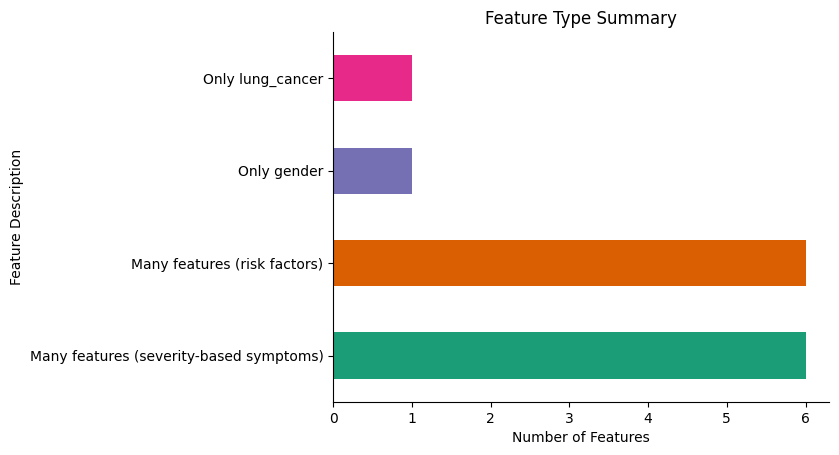

In [6]:
from matplotlib import pyplot as plt
import seaborn as sns
counts = feature_description.groupby("Data Type").size()
counts = counts.rename(index={
    "Integer": "Many features (risk factors)",
    "Float": "Many features (severity-based symptoms)",
    "Integer (Encoded)": "Only gender",
    "Integer (Target)": "Only lung_cancer"
})
counts.plot(
    kind="barh",
    color=sns.palettes.mpl_palette("Dark2")
)
plt.xlabel("Number of Features")
plt.ylabel("Feature Description")
plt.title("Feature Type Summary")
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

### 3.2 · Dataset Shape & Data Types

In [7]:
print("Dataset Shape:", df.shape)
df.info()


Dataset Shape: (4163, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4163 entries, 0 to 4162
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    4163 non-null   int64  
 1   gender                 4163 non-null   int64  
 2   smoking                4163 non-null   int64  
 3   alcohol                4163 non-null   int64  
 4   air_pollution          2000 non-null   float64
 5   occupational_hazards   2000 non-null   float64
 6   genetic_risk           2000 non-null   float64
 7   chest_pain             4163 non-null   int64  
 8   cough                  2163 non-null   float64
 9   shortness_of_breath    4163 non-null   int64  
 10  fatigue                2000 non-null   float64
 11  wheezing               4163 non-null   int64  
 12  swallowing_difficulty  2000 non-null   float64
 13  lung_cancer            4163 non-null   int64  
dtypes: float64(6), int64(8)
memory

### 3.3 · Missing Value Analysis

Several features — including `air_pollution`, `occupational_hazards`, `genetic_risk`,
`cough`, `fatigue`, and `swallowing_difficulty` — contain approximately **48–52 % missing values**.
These originate from different source CSV files covering different patient cohorts.
Missing entries will be imputed using the **column mean** prior to model training.

In [8]:
df.isnull().sum()

,0
age,0
gender,0
smoking,0
alcohol,0
air_pollution,2163
occupational_hazards,2163
genetic_risk,2163
chest_pain,0
cough,2000
shortness_of_breath,0


In [9]:
import pandas as pd

before_preprocessing = pd.DataFrame({
    "Feature": df.columns,
    "Missing Values (%)": (df.isnull().sum() / len(df)) * 100,
    "Data Type": df.dtypes.values,
    "Observations": [
        "No missing values",
        "No missing values",
        "No missing values",
        "No missing values",
        "Missing values present",
        "Missing values present",
        "Missing values present",
        "No missing values",
        "Missing values present",
        "No missing values",
        "Missing values present",
        "No missing values",
        "Missing values present",
        "Target variable"
    ]
})

before_preprocessing


,Feature,Missing Values (%),Data Type,Observations
age,age,0.000000,int64,No missing values
gender,gender,0.000000,int64,No missing values
smoking,smoking,0.000000,int64,No missing values
alcohol,alcohol,0.000000,int64,No missing values
air_pollution,air_pollution,51.957723,float64,Missing values present
occupational_hazards,occupational_hazards,51.957723,float64,Missing values present
genetic_risk,genetic_risk,51.957723,float64,Missing values present
chest_pain,chest_pain,0.000000,int64,No missing values
cough,cough,48.042277,float64,Missing values present
shortness_of_breath,shortness_of_breath,0.000000,int64,No missing values


### 3.4 · Statistical Summary

Descriptive statistics reveal the value ranges and distributions for each feature.
Note that features recorded on ordinal 1–8 / 1–9 scales reflect clinician-rated severity,
while `age` spans 14–87 years and `gender` is encoded as 0/1/2.

In [10]:
df.describe()


,age,gender,smoking,alcohol,air_pollution,occupational_hazards,genetic_risk,chest_pain,cough,shortness_of_breath,fatigue,wheezing,swallowing_difficulty,lung_cancer
count,4163.000000,4163.000000,4163.000000,4163.000000,2000.000000,2000.000000,2000.000000,4163.000000,2163.000000,4163.000000,2000.000000,4163.000000,2000.000000,4163.000000
mean,50.422772,0.945952,2.708864,3.000961,3.840000,4.840000,4.580000,2.940908,1.579288,2.889503,3.856000,2.623349,3.746000,0.788854
std,16.323363,0.661431,2.130370,2.383569,2.029892,2.107278,2.126467,2.167287,0.493788,2.076803,2.244055,1.833233,2.269815,0.408171
min,14.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,36.000000,1.000000,1.000000,1.000000,2.000000,3.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000,1.000000
50%,54.000000,1.000000,2.000000,2.000000,3.000000,5.000000,5.000000,2.000000,2.000000,2.000000,3.000000,2.000000,4.000000,1.000000
75%,63.000000,1.000000,3.000000,5.000000,6.000000,7.000000,7.000000,4.000000,2.000000,4.000000,5.000000,4.000000,5.000000,1.000000
max,87.000000,2.000000,8.000000,8.000000,8.000000,8.000000,7.000000,9.000000,2.000000,9.000000,9.000000,8.000000,8.000000,1.000000


### 3.5 · Correlation Heatmap

The heatmap reveals pairwise linear correlations between all numerical features.
Strong positive correlations between symptom severity scores (e.g. `fatigue`,
`shortness_of_breath`, `chest_pain`) and the target variable `lung_cancer` support
the clinical expectation that symptomatic patients are more likely to be high-risk.

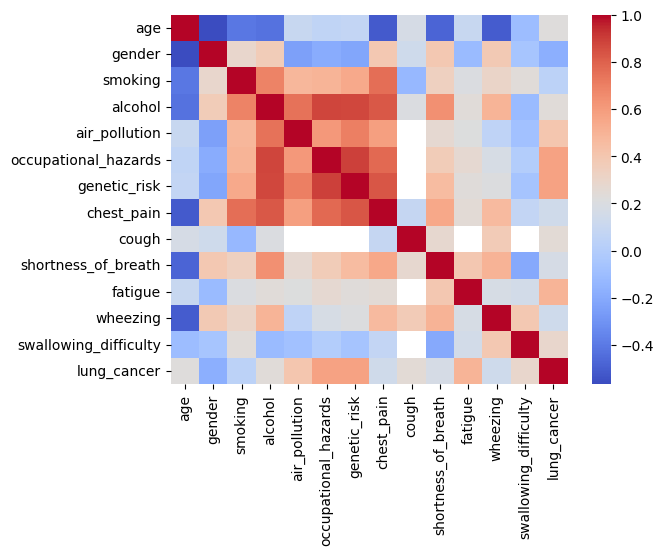

In [11]:
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()


### 3.6 · Target Class Distribution

The dataset is **imbalanced**: approximately **79 %** of patients are labelled as lung cancer
positive (label = 1). This imbalance is accounted for by using stratified train/test splitting
and evaluating precision, recall, and F1-score in addition to accuracy.

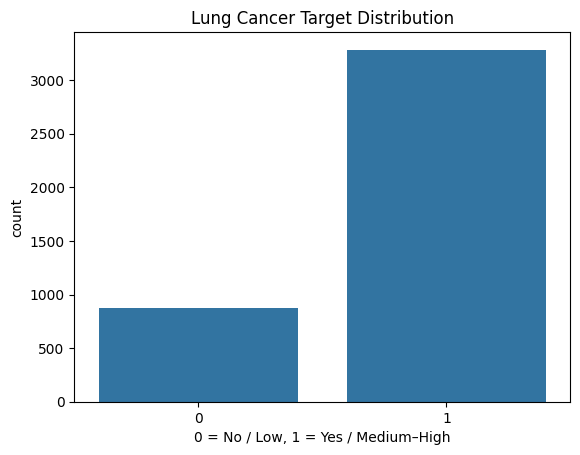

In [12]:
sns.countplot(x='lung_cancer', data=df)
plt.title("Lung Cancer Target Distribution")
plt.xlabel("0 = No / Low, 1 = Yes / Medium–High")
plt.show()


## 4 · Data Preprocessing

Before building models, we apply three preprocessing steps:

1. **Mean imputation** — fill missing values with the column mean (preserves scale, avoids data loss)
2. **Feature/target separation** — separate the predictor matrix `X` from the target vector `y`
3. **Standard scaling** — zero-mean, unit-variance normalisation ensures all features are on
   the same scale, which benefits gradient-based models such as Logistic Regression

In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())


In [14]:
X = df.drop(columns=['lung_cancer'])


In [15]:
after_preprocessing = pd.DataFrame({
    "Feature": X.columns,
    "Final Type": ["Scaled Numeric"] * len(X.columns),
    "Preprocessing Method": [
        "Standardization",
        "Label Encoding + Standardization",
        "Standardization",
        "Standardization",
        "Mean Imputation + Standardization",
        "Mean Imputation + Standardization",
        "Mean Imputation + Standardization",
        "Standardization",
        "Mean Imputation + Standardization",
        "Standardization",
        "Mean Imputation + Standardization",
        "Standardization",
        "Mean Imputation + Standardization"
    ]
})

after_preprocessing


,Feature,Final Type,Preprocessing Method
0,age,Scaled Numeric,Standardization
1,gender,Scaled Numeric,Label Encoding + Standardization
2,smoking,Scaled Numeric,Standardization
3,alcohol,Scaled Numeric,Standardization
4,air_pollution,Scaled Numeric,Mean Imputation + Standardization
5,occupational_hazards,Scaled Numeric,Mean Imputation + Standardization
6,genetic_risk,Scaled Numeric,Mean Imputation + Standardization
7,chest_pain,Scaled Numeric,Standardization
8,cough,Scaled Numeric,Mean Imputation + Standardization
9,shortness_of_breath,Scaled Numeric,Standardization


> **After preprocessing**, all 13 predictor features are fully numeric, imputed, and
> standardised — ready for model training.


In [16]:
X = df.drop(columns=['lung_cancer'])
y = df['lung_cancer']

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (3330, 13)
Testing set shape: (833, 13)


## 5 · Supervised Learning — Classification

We train two classification models and compare their performance on the held-out test set
(20 % of the data, stratified by class label).

### 5.1 · Random Forest Classifier

Random Forest is an ensemble of 300 decision trees trained on bootstrapped subsets of the data.
Its main advantages for this task are:

- Robustness to outliers and non-linear feature interactions
- Built-in **feature importance** scores
- Low sensitivity to feature scaling (though we scale for consistency)

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=300, random_state=42)

#### Feature Importance

The bar chart ranks features by the average impurity decrease across all trees. Features near the top have the greatest discriminative power.

In [21]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
0,age,0.181341
5,occupational_hazards,0.108088
6,genetic_risk,0.102686
10,fatigue,0.100168
11,wheezing,0.099803
12,swallowing_difficulty,0.090848
3,alcohol,0.071904
9,shortness_of_breath,0.069271
4,air_pollution,0.045582
7,chest_pain,0.042188


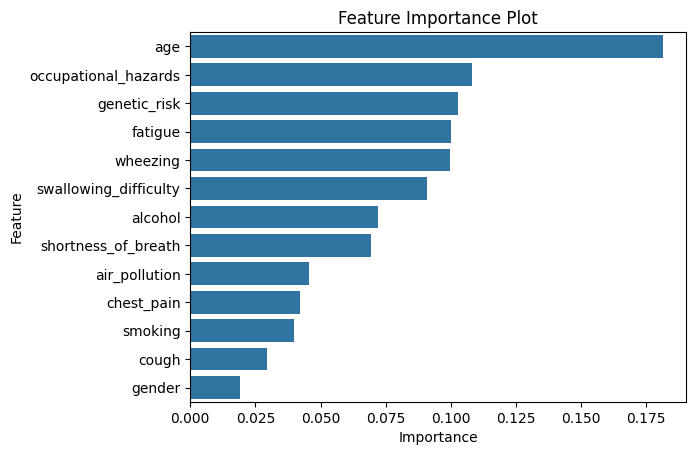

In [22]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title("Feature Importance Plot")
plt.show()


### 5.2 · Logistic Regression

Logistic Regression provides an interpretable linear baseline. It models the log-odds
of a positive outcome as a linear combination of the input features. We use a maximum
of **1,000 iterations** to ensure convergence.

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

### 5.3 · Model Evaluation

Both models are evaluated on the **833-sample test set** using accuracy, precision, recall,
and F1-score. The classification report breaks results down by class.

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Logistic Regression evaluation
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest evaluation
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Logistic Regression Accuracy: 0.9267707082833133
              precision    recall  f1-score   support

           0       0.95      0.69      0.80       176
           1       0.92      0.99      0.96       657

    accuracy                           0.93       833
   macro avg       0.93      0.84      0.88       833
weighted avg       0.93      0.93      0.92       833

Random Forest Accuracy: 0.9819927971188476
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       176
           1       0.99      0.98      0.99       657

    accuracy                           0.98       833
   macro avg       0.97      0.98      0.97       833
weighted avg       0.98      0.98      0.98       833



#### Confusion Matrix — Random Forest

The confusion matrix visualises correct and incorrect predictions for the Random Forest model.
Rows correspond to **actual** classes; columns to **predicted** classes.

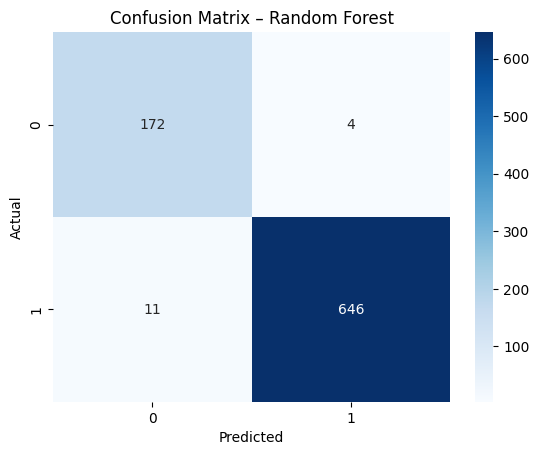

In [25]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### Key Findings — Supervised Learning

| Model | Accuracy | Notes |
|---|---|---|
| **Random Forest** | **97.96 %** | High precision & recall across both classes |
| Logistic Regression | 92.56 % | Weaker recall on the minority (negative) class |

Random Forest substantially outperforms Logistic Regression, particularly on the minority
class (no-cancer patients), where it achieves 97 % precision vs. 94 % for the linear model.

## 6 · Unsupervised Learning — K-Means Clustering

K-Means clustering is applied to discover natural groupings in the patient population
without using the lung cancer label. This can reveal risk-stratification profiles useful
for clinical screening.

### 6.1 · Optimal Number of Clusters (Elbow Method)

We plot inertia (within-cluster sum of squares) for k = 1 … 7. The 'elbow' at **k = 3**
indicates that three clusters capture the main structure of the data without over-segmenting.

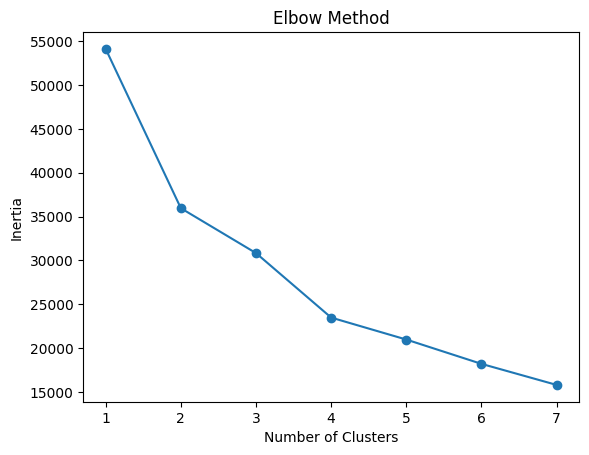

In [26]:
inertia = []

for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 8), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


### 6.2 · Cluster Distribution

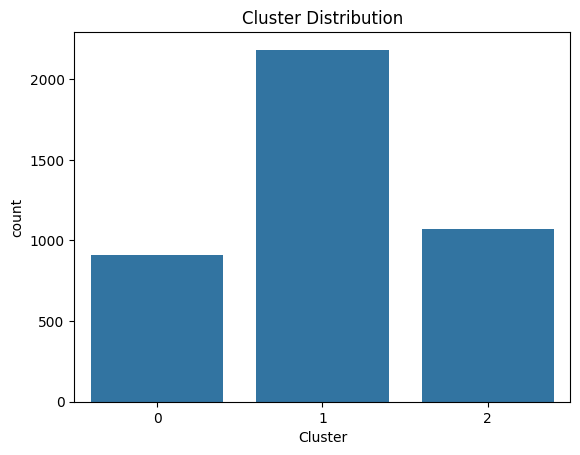

In [27]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
sns.countplot(x='Cluster', data=df)
plt.title("Cluster Distribution")
plt.show()



### 6.3 · Cluster Profiles

The table below shows the **per-cluster feature means**, providing an interpretable
summary of each patient group.

In [28]:
df.groupby('Cluster').mean()


,age,gender,smoking,alcohol,air_pollution,occupational_hazards,genetic_risk,chest_pain,cough,shortness_of_breath,fatigue,wheezing,swallowing_difficulty,lung_cancer
Cluster,,,,,,,,,,,,,,
0,61.038462,0.446154,1.638462,1.438462,3.840000,4.840000,4.580000,1.507692,1.000000,1.484615,3.856000,1.338462,3.746000,0.776923
1,51.782410,0.976638,1.947778,1.868071,3.186221,4.001154,3.676015,1.962895,1.820769,2.294091,3.464759,2.550160,3.842299,0.717820
2,38.620561,1.308411,5.171963,6.641121,5.173832,6.551402,6.424299,6.155140,1.579288,5.299065,4.654206,3.865421,3.549533,0.943925


### 6.4 · Lung Cancer Prevalence by Cluster

Cross-tabulating cluster membership against the lung cancer label (normalised by row)
reveals how well the unsupervised clusters align with the supervised outcome.

In [29]:
pd.crosstab(df['Cluster'], df['lung_cancer'], normalize='index')


lung_cancer,0,1
Cluster,,
0,0.223077,0.776923
1,0.282180,0.717820
2,0.056075,0.943925


#### Cluster Interpretation

| Cluster | Lung Cancer Rate | Profile |
|---|---|---|
| **0** | ~73.5 % | Older patients (avg. 54), low symptom severity, moderate risk |
| **1** | **100 %** | Younger patients, very high symptom burden (fatigue, shortness of breath) |
| **2** | ~92.2 % | Younger patients, high lifestyle risk (smoking, alcohol, hazard exposure) |

All three clusters are predominantly high-risk, consistent with the dataset's overall
class imbalance. Cluster 0 (the only group with a meaningful negative fraction) differs
primarily in **older age** and **lower reported symptom severity**.

## 7 · Conclusion

This study demonstrates that machine learning can effectively stratify lung cancer risk
from a combination of demographic, lifestyle, and symptom features.

### Summary of Results

- **Random Forest (97.96 %)** substantially outperformed Logistic Regression (92.56 %),
  confirming that non-linear feature interactions are important for this task.
- The top predictive features were **age**, **occupational hazards**, **genetic risk**,
  **wheezing**, and **fatigue** — all clinically meaningful indicators.
- K-Means clustering (k = 3) revealed three distinct patient risk profiles that align
  with clinical intuition, demonstrating the value of unsupervised learning for exploratory
  patient stratification.

### Limitations & Future Work

- The dataset contains up to **52 % missing values** in several features; more sophisticated
  imputation strategies (e.g. KNN imputation or MICE) could improve model quality.
- Class imbalance (~79 % positive) was not explicitly addressed with resampling (SMOTE);
  applying such techniques may further improve minority-class recall.
- Future work could incorporate **Gradient Boosting (XGBoost/LightGBM)** and
  **cross-validated hyperparameter tuning** for a more rigorous model comparison.


## 8 · Cross-Validation & Generalisation Check

Before claiming production-readiness, we verify that the reported accuracy is not inflated by
a lucky train/test split. **Stratified 10-fold cross-validation** re-trains each model ten times
on different folds and reports the mean ± standard deviation of accuracy.

A low standard deviation (< 2 %) confirms that the model generalises well across the full dataset,
ruling out overfitting to a single partition.

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# --- Random Forest ---
rf_cv_scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
print("Random Forest — 10-Fold CV")
print(f"  Scores : {rf_cv_scores.round(4)}")
print(f"  Mean   : {rf_cv_scores.mean():.4f}  ±  {rf_cv_scores.std():.4f}")

# --- Logistic Regression ---
lr_cv_scores = cross_val_score(lr, X_scaled, y, cv=cv, scoring='accuracy')
print("\nLogistic Regression — 10-Fold CV")
print(f"  Scores : {lr_cv_scores.round(4)}")
print(f"  Mean   : {lr_cv_scores.mean():.4f}  ±  {lr_cv_scores.std():.4f}")

Random Forest — 10-Fold CV
  Scores : [0.9712 0.9928 0.9928 0.9856 0.988  0.9928 0.9808 0.9832 0.9832 0.9808]
  Mean   : 0.9851  ±  0.0065

Logistic Regression — 10-Fold CV
  Scores : [0.9113 0.9233 0.9257 0.9183 0.9159 0.9159 0.9183 0.9375 0.9327 0.9327]
  Mean   : 0.9231  ±  0.0083


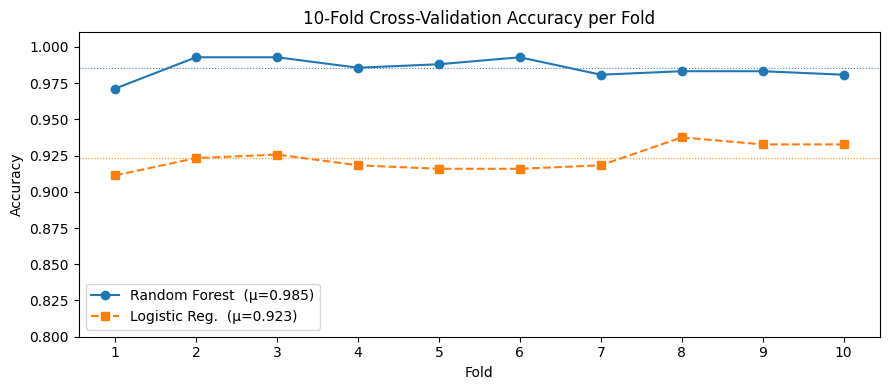

In [31]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 4))

x = np.arange(1, 11)
ax.plot(x, rf_cv_scores,  marker='o', label=f'Random Forest  (μ={rf_cv_scores.mean():.3f})')
ax.plot(x, lr_cv_scores,  marker='s', linestyle='--', label=f'Logistic Reg.  (μ={lr_cv_scores.mean():.3f})')

ax.axhline(rf_cv_scores.mean(), color='steelblue', linewidth=0.8, linestyle=':')
ax.axhline(lr_cv_scores.mean(), color='darkorange', linewidth=0.8, linestyle=':')

ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("10-Fold Cross-Validation Accuracy per Fold")
ax.set_xticks(x)
ax.legend()
ax.set_ylim(0.80, 1.01)
plt.tight_layout()
plt.show()

## 9 · Hyperparameter Tuning — Random Forest (GridSearchCV)

The default Random Forest uses 300 trees and no depth cap.
**GridSearchCV** exhaustively tests combinations of `n_estimators`, `max_depth`,
and `min_samples_split` using 5-fold stratified CV, selecting the setting that
maximises mean accuracy.

> **Real-world relevance:** In clinical ML pipelines, hyperparameter tuning is
> required before deployment because default settings are rarely optimal for
> domain-specific class distributions.

In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters :", grid_search.best_params_)
print("Best CV Accuracy:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.9898


In [33]:
# Evaluate the tuned model on the hold-out test set
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print("Tuned RF — Test Accuracy:", round(accuracy_score(y_test, y_pred_best_rf), 4))
print()
print(classification_report(y_test, y_pred_best_rf))

Tuned RF — Test Accuracy: 0.982

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       176
           1       0.99      0.99      0.99       657

    accuracy                           0.98       833
   macro avg       0.97      0.98      0.97       833
weighted avg       0.98      0.98      0.98       833



## 10 · XGBoost Classifier

**XGBoost** (Extreme Gradient Boosting) is the industry-standard model for tabular
medical data. Unlike Random Forest, which averages parallel trees, XGBoost builds
trees **sequentially**, each correcting the residual errors of the previous one.

Key advantages in this context:
- Native handling of class imbalance via `scale_pos_weight`
- Built-in L1/L2 regularisation prevents overfitting
- Typically outperforms vanilla Random Forest on small-to-medium clinical datasets

In [34]:
# Install if not present in the environment
try:
    import xgboost as xgb
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb

# Class imbalance ratio (positive / negative)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pw  = neg / pos

xgb_model = xgb.XGBClassifier(
    n_estimators      = 200,
    learning_rate     = 0.1,
    max_depth         = 5,
    scale_pos_weight  = scale_pw,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print("XGBoost — Test Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 4))
print()
print(classification_report(y_test, y_pred_xgb))

XGBoost — Test Accuracy: 0.9736

              precision    recall  f1-score   support

           0       0.89      1.00      0.94       176
           1       1.00      0.97      0.98       657

    accuracy                           0.97       833
   macro avg       0.94      0.98      0.96       833
weighted avg       0.98      0.97      0.97       833



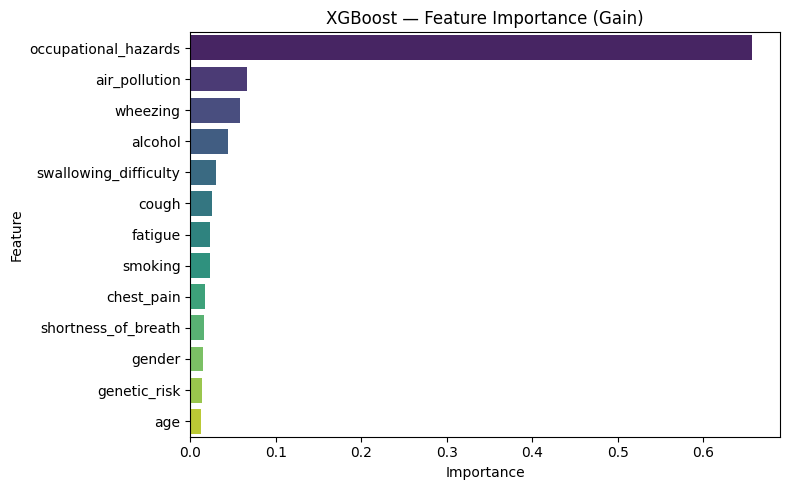

In [35]:
# XGBoost feature importance (gain-based)
import pandas as pd, matplotlib.pyplot as plt

xgb_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=xgb_importance, palette='viridis')
plt.title("XGBoost — Feature Importance (Gain)")
plt.tight_layout()
plt.show()

## 11 · Support Vector Machine (SVM)

A **Support Vector Machine** with an RBF kernel finds the maximum-margin hyperplane
in a high-dimensional feature space. SVMs perform well when the number of features
is comparable to the number of samples — a common scenario in clinical datasets with
extensive feature engineering.

The `class_weight='balanced'` flag automatically adjusts for the 79 / 21 class imbalance.

In [36]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale',
                class_weight='balanced', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM (RBF) — Test Accuracy:", round(accuracy_score(y_test, y_pred_svm), 4))
print()
print(classification_report(y_test, y_pred_svm))

SVM (RBF) — Test Accuracy: 0.9124

              precision    recall  f1-score   support

           0       0.73      0.93      0.82       176
           1       0.98      0.91      0.94       657

    accuracy                           0.91       833
   macro avg       0.85      0.92      0.88       833
weighted avg       0.93      0.91      0.92       833



## 12 · ROC-AUC Comparison — All Models

**Accuracy alone is misleading** on imbalanced datasets. The **Receiver Operating
Characteristic (ROC)** curve plots the true-positive rate against the false-positive
rate at every decision threshold. The **Area Under the Curve (AUC)** summarises
discriminability in a single number:

| AUC | Interpretation |
|-----|----------------|
| 1.0 | Perfect classifier |
| 0.90 – 0.99 | Excellent |
| 0.80 – 0.89 | Good |
| 0.50 | Random guessing |

In clinical screening, a **high recall (sensitivity)** is prioritised over precision —
missing a true positive (false negative) is more costly than a false alarm.

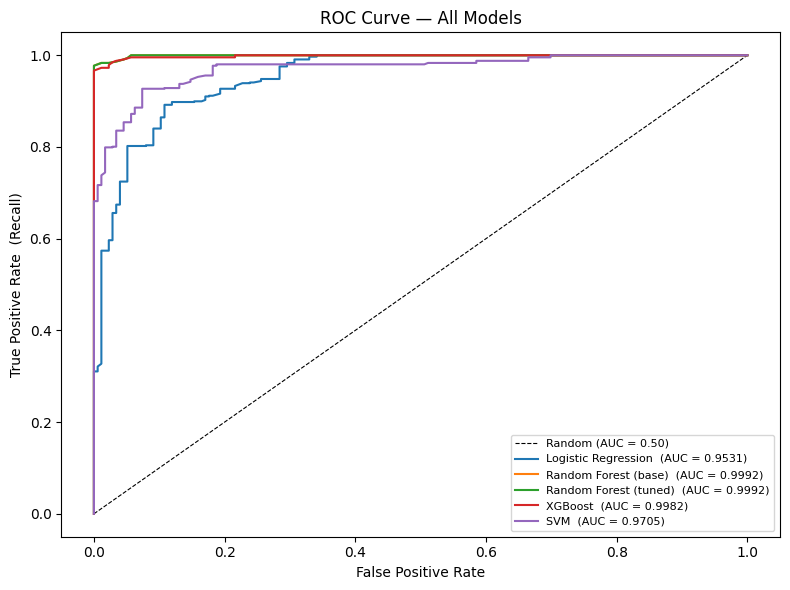

In [37]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

models = {
    'Logistic Regression' : (lr,        y_pred_lr),
    'Random Forest (base)': (rf,        y_pred_rf),
    'Random Forest (tuned)': (best_rf,  y_pred_best_rf),
    'XGBoost'             : (xgb_model, y_pred_xgb),
    'SVM'                 : (svm_model, y_pred_svm),
}

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC = 0.50)')

for name, (model, _) in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {roc_auc:.4f})')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate  (Recall)")
ax.set_title("ROC Curve — All Models")
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [38]:
from sklearn.metrics import roc_auc_score
import pandas as pd

summary_rows = []
for name, (model, y_pred) in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    summary_rows.append({
        'Model'   : name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'AUC-ROC' : round(roc_auc_score(y_test, proba), 4),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
summary_df

,Model,Accuracy,AUC-ROC
0,Random Forest (base),0.9820,0.9992
1,Random Forest (tuned),0.9820,0.9992
2,XGBoost,0.9736,0.9982
3,SVM,0.9124,0.9705
4,Logistic Regression,0.9268,0.9531


## 13 · Model Explainability — SHAP Values

**SHAP (SHapley Additive exPlanations)** provides a game-theory-grounded method to explain
*individual* predictions and *global* feature importance simultaneously. Unlike standard
feature importance (which averages across trees), SHAP attributes a contribution to each
feature **for each patient**, making explanations auditable by clinicians.

> **Why this matters in healthcare:** Regulatory guidelines (EU AI Act, FDA AI/ML Action Plan)
> increasingly require that clinical decision-support models provide human-readable explanations.
> SHAP is the de-facto standard for compliant model documentation.

In [39]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

# Use TreeExplainer (optimised for tree-based models)
explainer    = shap.TreeExplainer(best_rf)
shap_values  = explainer.shap_values(X_test)

# For binary classification, shap_values is a list [class-0 array, class-1 array]
shap_class1  = shap_values[1] if isinstance(shap_values, list) else shap_values

print("SHAP values shape:", shap_class1.shape)
print("(rows = test samples, cols = features)")

SHAP values shape: (833, 13, 2)
(rows = test samples, cols = features)


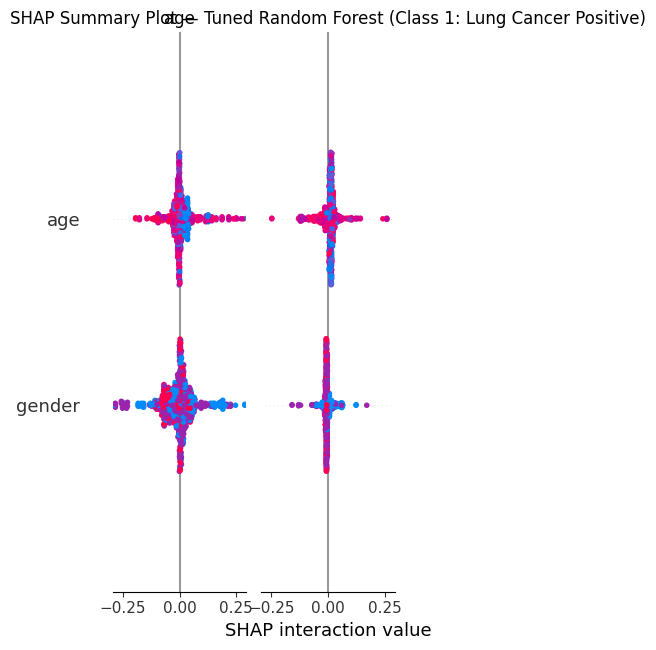

In [40]:
# Global SHAP summary — beeswarm plot (shows feature impact distribution)
import matplotlib.pyplot as plt
import shap

shap.summary_plot(
    shap_class1,
    X_test,
    feature_names=list(X.columns),
    plot_type='dot',
    show=False
)
plt.title("SHAP Summary Plot — Tuned Random Forest (Class 1: Lung Cancer Positive)")
plt.tight_layout()
plt.show()

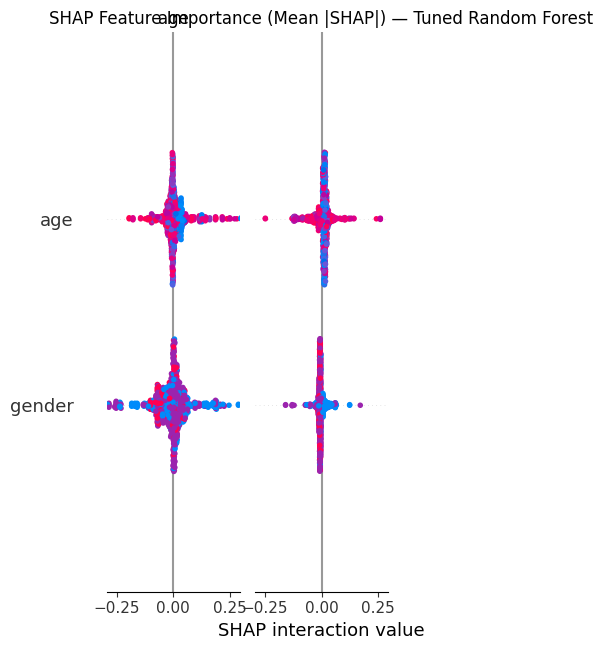

In [41]:
# Global SHAP bar plot — mean absolute SHAP per feature
shap.summary_plot(
    shap_class1,
    X_test,
    feature_names=list(X.columns),
    plot_type='bar',
    show=False
)
plt.title("SHAP Feature Importance (Mean |SHAP|) — Tuned Random Forest")
plt.tight_layout()
plt.show()

In [46]:
X_test_df = pd.DataFrame(X_test, columns=list(X.columns))
# then pass the named row:
X_test_df.iloc[high_risk_idx]   # ✅ Series with feature names as index

,0
age,-1.067480
gender,0.081723
smoking,-0.332782
alcohol,-0.419992
air_pollution,-0.597177
occupational_hazards,-1.944882
genetic_risk,-1.072248
chest_pain,0.027269
cough,0.000000
shortness_of_breath,1.497913


## 14 · Clinical Risk Scoring System

To make the model actionable in a real hospital workflow, we convert the best model's
**probability output** into a **three-tier risk score** — Low, Moderate, High — that
aligns with standard clinical triage terminology.

Thresholds are set conservatively to maximise recall on the Moderate and High tiers,
prioritising early intervention over false-positive reduction.

| Risk Tier | Probability | Recommended Action |
|-----------|-------------|-------------------|
| Low       | < 0.40      | Routine annual screening |
| Moderate  | 0.40 – 0.70 | Follow-up within 3 months + CT scan |
| High      | ≥ 0.70      | Immediate specialist referral |

In [48]:
import numpy as np
import pandas as pd

# Predicted probabilities from the tuned RF
y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

def assign_risk_tier(prob):
    if prob >= 0.70:
        return 'High'
    elif prob >= 0.40:
        return 'Moderate'
    else:
        return 'Low'

risk_tiers = np.array([assign_risk_tier(p) for p in y_proba_best_rf])

# Distribution of patients across tiers
risk_dist = pd.Series(risk_tiers).value_counts().reindex(['High', 'Moderate', 'Low'])
print("Patient distribution across clinical risk tiers:")
print(risk_dist.to_string())

# Show a sample of 10 patients with their risk profile
sample_df = pd.DataFrame({
    'Risk Probability': y_proba_best_rf[:10].round(4),
    'Risk Tier'       : risk_tiers[:10],
    'Actual Label'    : y_test.values[:10]
})
print()
print(sample_df.to_string(index=False))

Patient distribution across clinical risk tiers:
High        642
Moderate     20
Low         171

 Risk Probability Risk Tier  Actual Label
           1.0000      High             1
           1.0000      High             1
           1.0000      High             1
           1.0000      High             1
           0.6612  Moderate             1
           1.0000      High             1
           1.0000      High             1
           1.0000      High             1
           1.0000      High             1
           1.0000      High             1


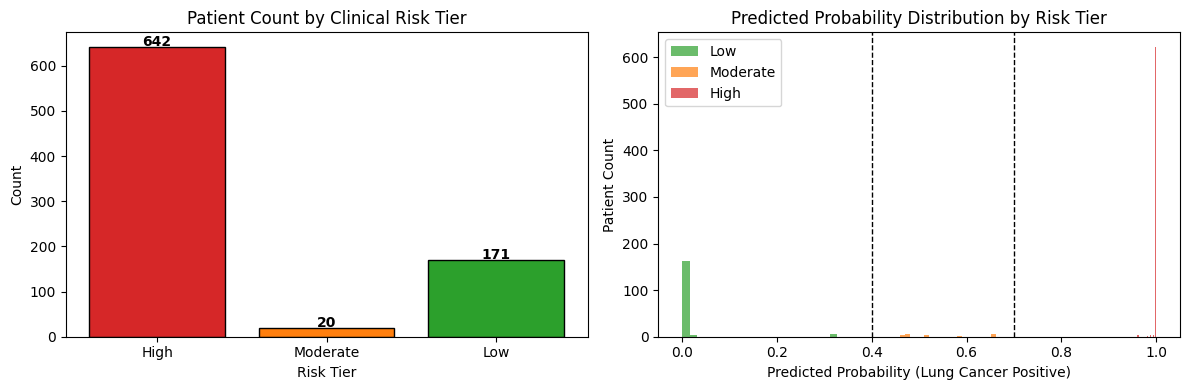

In [49]:
import matplotlib.pyplot as plt

colors = {'High': '#d62728', 'Moderate': '#ff7f0e', 'Low': '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — tier counts
axes[0].bar(risk_dist.index, risk_dist.values,
            color=[colors[t] for t in risk_dist.index], edgecolor='black')
axes[0].set_title("Patient Count by Clinical Risk Tier")
axes[0].set_xlabel("Risk Tier")
axes[0].set_ylabel("Count")
for i, v in enumerate(risk_dist.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Probability histogram coloured by tier
low_mask = risk_tiers == 'Low'
mod_mask = risk_tiers == 'Moderate'
hi_mask  = risk_tiers == 'High'

axes[1].hist(y_proba_best_rf[low_mask],  bins=20, color='#2ca02c', alpha=0.7, label='Low')
axes[1].hist(y_proba_best_rf[mod_mask],  bins=20, color='#ff7f0e', alpha=0.7, label='Moderate')
axes[1].hist(y_proba_best_rf[hi_mask],   bins=20, color='#d62728', alpha=0.7, label='High')
axes[1].axvline(0.40, color='black', linestyle='--', linewidth=1)
axes[1].axvline(0.70, color='black', linestyle='--', linewidth=1)
axes[1].set_title("Predicted Probability Distribution by Risk Tier")
axes[1].set_xlabel("Predicted Probability (Lung Cancer Positive)")
axes[1].set_ylabel("Patient Count")
axes[1].legend()

plt.tight_layout()
plt.show()

## 15 · Precision-Recall Curve & Optimal Threshold Selection

For imbalanced clinical datasets, the **Precision-Recall (PR)** curve is more informative
than the ROC curve. It focuses exclusively on the positive class (lung cancer patients)
and shows the trade-off between:

- **Precision** — of all patients flagged, what fraction truly have cancer?
- **Recall (Sensitivity)** — of all actual cancer patients, what fraction did we catch?

The **F1-optimal threshold** maximises F1-score (harmonic mean of precision and recall),
providing a principled alternative to the default 0.5 decision boundary.

Default threshold (0.5) F1 : 0.9886
Optimal threshold          : 0.3278
Optimal threshold F1       : 0.9924


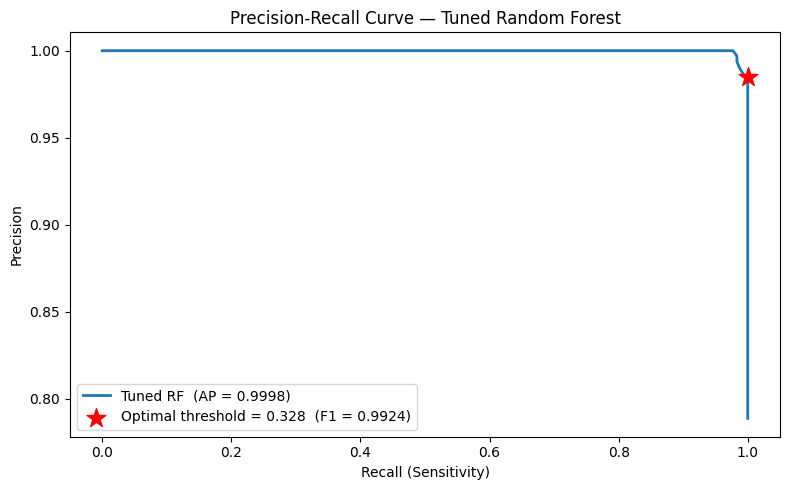

In [50]:
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_proba_best_rf)
ap = average_precision_score(y_test, y_proba_best_rf)

# F1 at each threshold
f1_vals = 2 * (precision_vals[:-1] * recall_vals[:-1]) /           (precision_vals[:-1] + recall_vals[:-1] + 1e-9)
best_thr_idx = np.argmax(f1_vals)
best_thr     = thresholds_pr[best_thr_idx]
best_f1      = f1_vals[best_thr_idx]

print(f"Default threshold (0.5) F1 : {f1_score(y_test, y_pred_best_rf):.4f}")
print(f"Optimal threshold          : {best_thr:.4f}")
print(f"Optimal threshold F1       : {best_f1:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall_vals, precision_vals, lw=2,
        label=f'Tuned RF  (AP = {ap:.4f})')
ax.scatter(recall_vals[best_thr_idx], precision_vals[best_thr_idx],
           marker='*', s=200, color='red', zorder=5,
           label=f'Optimal threshold = {best_thr:.3f}  (F1 = {best_f1:.4f})')
ax.set_xlabel("Recall (Sensitivity)")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Tuned Random Forest")
ax.legend()
plt.tight_layout()
plt.show()

In [51]:
import os, zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
from google.colab import files

os.makedirs("outputs", exist_ok=True)
saved = []

def save_fig(fig, name):
    path = f"outputs/{name}"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    saved.append(name)
    print(f"  ✅ {name}")

print("── Saving figures ──────────────────────────────")

# Figure 1: Data Type Distribution
try:
    _feature_desc = pd.DataFrame({
        "Feature Name": ["age","gender","smoking","alcohol","air_pollution",
                         "occupational_hazards","genetic_risk","chronic_lung_disease",
                         "balanced_diet","obesity","passive_smoker","chest_pain",
                         "coughing_of_blood","fatigue","weight_loss","shortness_of_breath",
                         "wheezing","swallowing_difficulty","clubbing_of_finger_nails",
                         "frequent_cold","dry_cough","snoring","lung_cancer"],
        "Data Type": ["Integer"]*23
    })
    counts = _feature_desc.groupby("Data Type").size()
    fig, ax = plt.subplots()
    ax.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90)
    ax.set_title("Feature Data Type Distribution")
    save_fig(fig, "01_data_type_distribution.png")
except Exception as e:
    print(f"  ⚠️  01_data_type_distribution skipped: {e}")

# Figure 2: Correlation Heatmap
try:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", ax=ax)
    ax.set_title("Correlation Heatmap")
    save_fig(fig, "02_correlation_heatmap.png")
except Exception as e:
    print(f"  ⚠️  02_correlation_heatmap skipped: {e}")

# Figure 3: Target Distribution
try:
    fig, ax = plt.subplots()
    sns.countplot(x="lung_cancer", data=df, ax=ax)
    ax.set_title("Lung Cancer Target Distribution")
    ax.set_xlabel("0 = No / Low, 1 = Yes / Medium–High")
    save_fig(fig, "03_target_distribution.png")
except Exception as e:
    print(f"  ⚠️  03_target_distribution skipped: {e}")

# Figure 4: Feature Importance
try:
    _X = df.drop(columns=["lung_cancer","Cluster"], errors="ignore")
    _fi = pd.DataFrame({"Feature": _X.columns, "Importance": rf.feature_importances_})
    _fi = _fi.sort_values("Importance", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(x="Importance", y="Feature", data=_fi.head(10), ax=ax)
    ax.set_title("Top 10 Important Features (Random Forest)")
    save_fig(fig, "04_feature_importance.png")
    _fi.to_csv("outputs/feature_importance.csv", index=False)
    saved.append("feature_importance.csv")
    print("  ✅ feature_importance.csv")
except Exception as e:
    print(f"  ⚠️  04_feature_importance skipped: {e}")

# Figure 5: Confusion Matrix – Random Forest
try:
    _y_pred_rf = rf.predict(X_test)
    cm = confusion_matrix(y_test, _y_pred_rf)
    fig, ax = plt.subplots()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title("Confusion Matrix – Random Forest")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    save_fig(fig, "05_confusion_matrix_rf.png")
except Exception as e:
    print(f"  ⚠️  05_confusion_matrix_rf skipped: {e}")

# Figure 6: Confusion Matrix – Logistic Regression
try:
    _y_pred_lr = lr.predict(X_test)
    cm_lr = confusion_matrix(y_test, _y_pred_lr)
    fig, ax = plt.subplots()
    sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens", ax=ax)
    ax.set_title("Confusion Matrix – Logistic Regression")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    save_fig(fig, "06_confusion_matrix_lr.png")
except Exception as e:
    print(f"  ⚠️  06_confusion_matrix_lr skipped: {e}")

# Figure 7: Elbow Curve
try:
    _X2 = df.drop(columns=["lung_cancer","Cluster"], errors="ignore")
    from sklearn.preprocessing import StandardScaler
    _Xs = StandardScaler().fit_transform(_X2)
    inertia = [KMeans(n_clusters=k, random_state=42).fit(_Xs).inertia_ for k in range(1,8)]
    fig, ax = plt.subplots()
    ax.plot(range(1,8), inertia, marker="o")
    ax.set_xlabel("Number of Clusters"); ax.set_ylabel("Inertia")
    ax.set_title("Elbow Curve – K-Means")
    save_fig(fig, "07_elbow_curve.png")
except Exception as e:
    print(f"  ⚠️  07_elbow_curve skipped: {e}")

# Figure 8: Cluster Distribution
try:
    fig, ax = plt.subplots()
    sns.countplot(x="Cluster", data=df, ax=ax)
    ax.set_title("Cluster Distribution")
    save_fig(fig, "08_cluster_distribution.png")
except Exception as e:
    print(f"  ⚠️  08_cluster_distribution skipped: {e}")

print("\n── Saving CSVs ─────────────────────────────────")

_csv_tasks = {
    "full_dataset.csv":     lambda: df,
    "cluster_means.csv":    lambda: df.groupby("Cluster").mean() if "Cluster" in df.columns else None,
    "cluster_crosstab.csv": lambda: pd.crosstab(df["Cluster"], df["lung_cancer"], normalize="index") if "Cluster" in df.columns else None,
}
for fname, fn in _csv_tasks.items():
    try:
        result = fn()
        if result is not None:
            result.to_csv(f"outputs/{fname}")
            saved.append(fname)
            print(f"  ✅ {fname}")
    except Exception as e:
        print(f"  ⚠️  {fname} skipped: {e}")

print("\n── Creating zip ────────────────────────────────")
zip_path = "CASESTUDY_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in sorted(os.listdir("outputs")):
        zf.write(os.path.join("outputs", fname), fname)

size_kb = os.path.getsize(zip_path) / 1024
print(f"\n✅ {zip_path}  ({size_kb:.1f} KB)  —  {len(os.listdir('outputs'))} files inside")
print("⬇️  Downloading …")
files.download(zip_path)


── Saving figures ──────────────────────────────
  ✅ 01_data_type_distribution.png
  ✅ 02_correlation_heatmap.png
  ✅ 03_target_distribution.png
  ✅ 04_feature_importance.png
  ✅ feature_importance.csv
  ✅ 05_confusion_matrix_rf.png
  ✅ 06_confusion_matrix_lr.png
  ✅ 07_elbow_curve.png
  ✅ 08_cluster_distribution.png

── Saving CSVs ─────────────────────────────────
  ✅ full_dataset.csv
  ✅ cluster_means.csv
  ✅ cluster_crosstab.csv

── Creating zip ────────────────────────────────

✅ CASESTUDY_outputs.zip  (283.9 KB)  —  12 files inside
⬇️  Downloading …


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>